In [6]:
import re
import csv

def clean_telemetry(input_file, output_file):
    # Regex to capture the timestamp and the comma-separated payload
    pattern = re.compile(r"^(\[\d{2}:\d{2}:\d{2}\.\d{3}\]) <state;\d+;([^;]+);[0-9A-Fa-f]{2}>")
    
    # Exact headers for the 11 hardware variables + Timestamp
    header = ["Timestamp", "Motor", "Steering", "CamPitch", "CamYaw", 
              "AccelX", "AccelY", "AccelZ", "GyroX", "GyroY", "GyroZ", "ToF"]

    processed_lines = 0

    with open(input_file, 'r', encoding='utf-8') as infile, \
         open(output_file, 'w', newline='', encoding='utf-8') as outfile:
        
        writer = csv.writer(outfile)
        writer.writerow(header)
        
        for line in infile:
            line = line.strip()
            if not line:
                continue
                
            match = pattern.search(line)
            if match:
                timestamp = match.group(1)
                payload = match.group(2)
                
                # Split the 11 hardware variables
                raw_values = payload.split(',')
                
                # Format to 2 decimal places (strips out '-0.00' anomalies)
                formatted_hardware = [f"{float(val):.2f}" for val in raw_values]
                
                # Build the complete row
                row = [timestamp] + formatted_hardware
                writer.writerow(row)
                processed_lines += 1

    print(f"Done! Cleaned {processed_lines} lines.")
    print(f"Saved to: {output_file}")

if __name__ == "__main__":
    INPUT_FILE = "real/6. jazda swobodna.txt" 
    OUTPUT_FILE = "real_cleaned/6. jazda swobodna.csv"
    
    clean_telemetry(INPUT_FILE, OUTPUT_FILE)

Done! Cleaned 4110 lines.
Saved to: real_cleaned/6. jazda swobodna.csv


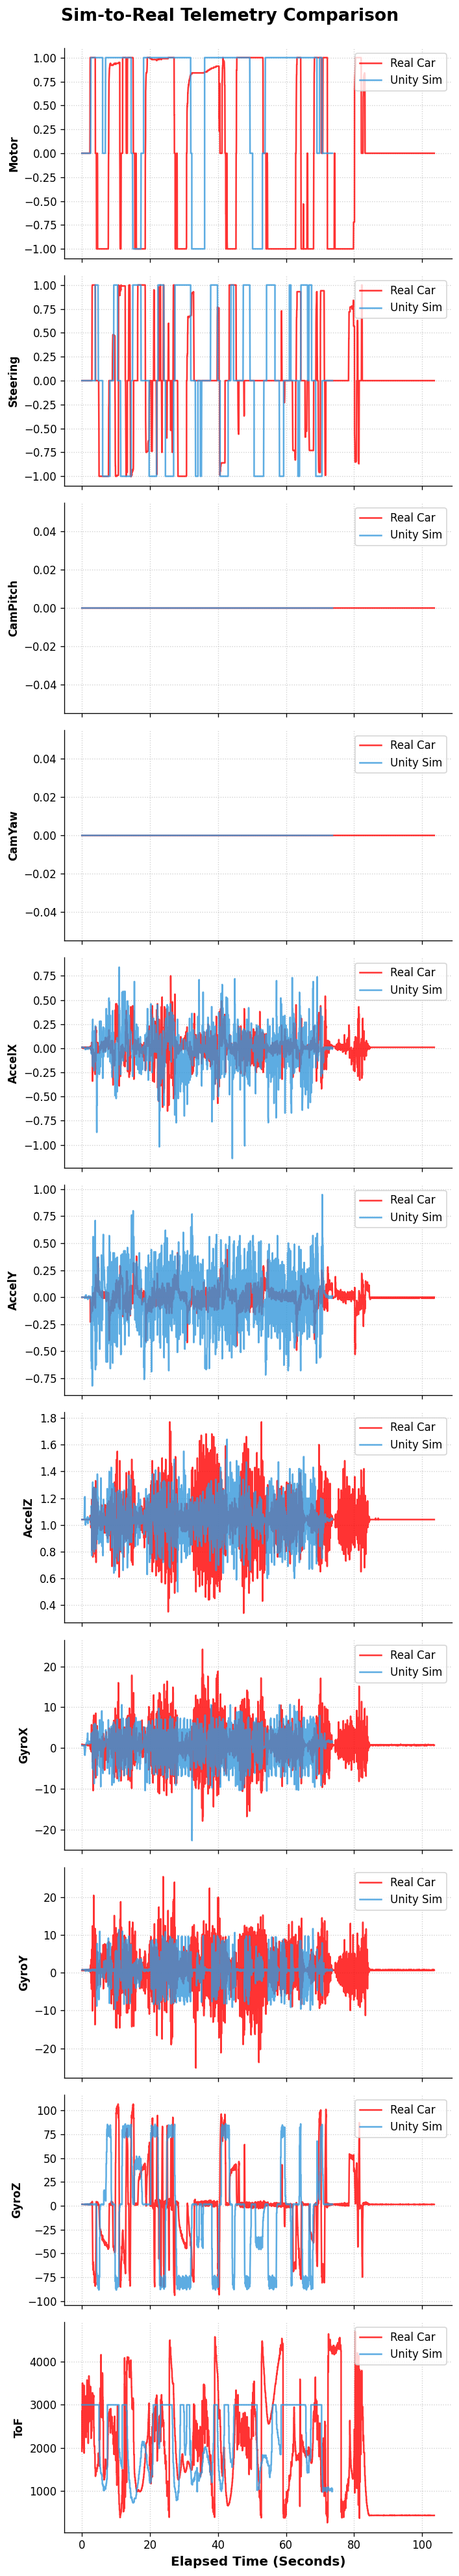

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def prep_data(filepath):
    df = pd.read_csv(filepath, header=0)
    df['Timestamp'] = df['Timestamp'].str.strip('[]')
    df['Datetime'] = pd.to_datetime(df['Timestamp'], format='%H:%M:%S.%f')
    df['Time_s'] = (df['Datetime'] - df['Datetime'].iloc[0]).dt.total_seconds()
    return df

def plot_sim_vs_real(real_df, sim_df, columns_to_plot):
    num_plots = len(columns_to_plot)
    fig, axes = plt.subplots(num_plots, 1, figsize=(6, 3 * num_plots), sharex=True, dpi=120)
    if num_plots == 1:
        axes = [axes]

    real_style = {'color': 'r', 'label': 'Real Car', 'linewidth': 1.5, 'alpha': 0.8}
    sim_style  = {'color': '#3498db', 'label': 'Unity Sim', 'linewidth': 1.5, 'alpha': 0.8}

    for i, col in enumerate(columns_to_plot):
        ax = axes[i]
        
        # Plot Real Data
        if col in real_df.columns:
            ax.plot(real_df['Time_s'], real_df[col], **real_style)
            
        # Plot Sim Data
        if col in sim_df.columns:
            ax.plot(sim_df['Time_s'], sim_df[col], **sim_style)
            
        # Formatting the subplot
        ax.set_ylabel(col, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right')
        
        # Clean up borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Set the bottom X-axis label
    axes[-1].set_xlabel('Elapsed Time (Seconds)', fontweight='bold', fontsize=12)
    
    # Add a main title
    fig.suptitle('Sim-to-Real Telemetry Comparison', fontsize=16, fontweight='bold', y=1.0)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 1. Load and prep data
    real_data = prep_data('real/6. jazda swobodna.csv')
    sim_data = prep_data('sim/jazda swobodna.csv')
    
    # 2. Define exactly which sensors you want to analyze in this run
    # You can easily add 'AccelX', 'GyroZ', 'Motor', etc. here.
    sensors_to_analyze = [
        'Motor',
        'Steering',
        'CamPitch',
        'CamYaw',
        'AccelX',
        'AccelY',
        'AccelZ',
        'GyroX',
        'GyroY',
        'GyroZ',
        'ToF'
    ]
    
    # 3. Generate the plot
    plot_sim_vs_real(real_data, sim_data, sensors_to_analyze)